# WriteLens, Feature Engineering

Lanjutan dari notebook EDA. Sekarang kita ekstrak fitur stylometric dari tiap teks, terus dilihat mana yang paling bisa bedain human vs AI.

Output utama:
- `data/processed/all_features.csv`: semua fitur, semua data
- `data/processed/features_final.csv`: fitur terpilih + label, siap training
- `data/processed/feature_ranges.json`: range tipikal human/AI per fitur (dipake app)
- Plot di `data/processed/plots/`


## Section 1. Setup + Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import json
import warnings
from collections import Counter
from scipy import stats
from tqdm import tqdm
tqdm.pandas()
warnings.filterwarnings('ignore')

PLOTS_DIR = "../data/processed/plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor': '#0E0E16',
    'axes.facecolor': '#14141E',
    'axes.edgecolor': '#2A2A3C',
    'axes.labelcolor': '#E8E8ED',
    'text.color': '#E8E8ED',
    'xtick.color': '#8888A0',
    'ytick.color': '#8888A0',
    'grid.color': '#1E1E2E',
    'font.family': 'sans-serif',
    'font.size': 11,
})

TEAL  = "#4ECDC4"
CORAL = "#F47C7C"
AMBER = "#F0C05A"
GREEN = "#5EE0A0"
MUTED = "#8888A0"

def savefig(name):
    plt.savefig(os.path.join(PLOTS_DIR, name), dpi=150, bbox_inches='tight', facecolor='#0E0E16')


Load cleaned data dari notebook EDA.

In [2]:
daigt = pd.read_csv("../data/processed/daigt_v2_clean.csv")
mage  = pd.read_csv("../data/processed/mage_clean.csv")
print("DAIGT clean:", daigt.shape)
print("MAGE clean: ", mage.shape)
daigt.head(2)


DAIGT clean: (44866, 5)
MAGE clean:  (371981, 4)


,text,label,source,prompt_name,dataset
0,Phones\n\nModern humans today are always on th...,0,persuade_corpus,Phones and driving,daigt_v2
1,This essay will explain if drivers should or s...,0,persuade_corpus,Phones and driving,daigt_v2


## Section 2. Definisi Fitur

Kita extract sekitar 20 fitur stylometric per teks, dikelompokin jadi 6 kategori:

- **Sentence-level (4):** rata-rata panjang kalimat, std panjang kalimat, rasio kalimat pendek (<8 kata), rasio kalimat panjang (>25 kata)
- **Lexical diversity (3):** TTR, hapax ratio, rata-rata panjang kata
- **Word choice (3):** rasio function words, rate kata sambung, diversity pronoun
- **Punctuation (4):** densitas tanda baca, rasio koma, rasio tanda tanya, rasio tanda seru
- **Readability (3):** suku kata per kata, Flesch reading ease, jumlah paragraf
- **Pattern (3):** rate bigram berulang, densitas kata transisi, estimasi kalimat pasif

Total 20 fitur. Hipotesisnya: AI cenderung lebih konsisten panjang kalimatnya, lebih banyak kata transisi, lebih jarang pakai konstruksi yang variatif.


## Section 3. Fungsi Extraction

Word sets buat dipake di dalam fungsi. Taruh di luar biar nggak di-rebuild tiap call.

In [3]:
STOPWORDS = {
    "the", "a", "an", "and", "or", "but", "of", "to", "in", "on", "at",
    "for", "with", "is", "are", "was", "were", "be", "been", "being",
    "have", "has", "had", "do", "does", "did", "i", "you", "he", "she",
    "it", "we", "they", "this", "that", "these", "those", "by", "as",
    "not", "from", "so", "if", "its", "my", "your", "our", "their",
    "which", "what", "when", "where", "who", "whom", "how",
    "all", "each", "every", "both", "few", "more", "most", "other",
    "some", "such", "no", "nor", "only", "own", "same", "than",
    "too", "very", "can", "will", "just", "should", "now",
}

CONJUNCTIONS = {
    "and", "but", "or", "nor", "for", "yet", "so",
    "however", "moreover", "furthermore", "additionally",
    "nevertheless", "meanwhile", "therefore", "consequently",
    "although", "whereas", "while",
}

TRANSITION_WORDS = {
    "however", "therefore", "moreover", "furthermore", "additionally",
    "consequently", "nevertheless", "meanwhile", "similarly",
    "subsequently", "accordingly", "conversely", "alternatively",
    "specifically", "particularly", "notably", "indeed",
}

PRONOUNS = {
    "i", "me", "my", "mine", "myself",
    "you", "your", "yours", "yourself",
    "he", "him", "his", "himself",
    "she", "her", "hers", "herself",
    "it", "its", "itself",
    "we", "us", "our", "ours", "ourselves",
    "they", "them", "their", "theirs", "themselves",
}

VOWEL_RE   = re.compile(r'[aeiouy]+')
WORD_RE    = re.compile(r"[A-Za-z']+")
SENT_RE    = re.compile(r'[.!?]+(?:\s|$)')
PUNCT_RE   = re.compile(r'[.,;:!?\-"\'()\[\]]')
PASSIVE_RE = re.compile(r'\b(?:was|were|been|be|is|are)\s+\w+ed\b')


Fungsi syllable counter sederhana. Hitung kelompok vokal per kata, minimal 1. Kalau ending 'e' dan count > 1, kurangi satu (heuristik biasa, lumayan akurat).

In [4]:
def count_syllables(word):
    word = word.lower()
    groups = VOWEL_RE.findall(word)
    n = len(groups)
    if n == 0:
        return 1
    if word.endswith('e') and n > 1:
        n -= 1
    return n


Fungsi utama: `extract_features(text)`. Return dict 20 fitur, atau `None` kalau teksnya terlalu pendek / nggak valid.

In [5]:
def extract_features(text):
    try:
        text = str(text)
        if len(text) < 20:
            return None

        sents_raw = SENT_RE.split(text)
        sents = [s.strip() for s in sents_raw if s.strip()]
        if len(sents) < 1:
            return None

        words = WORD_RE.findall(text)
        words_lower = [w.lower() for w in words]
        n_words = len(words)
        if n_words < 5:
            return None

        sent_word_counts = [len(WORD_RE.findall(s)) for s in sents]
        sent_word_counts = [c for c in sent_word_counts if c > 0]
        if not sent_word_counts:
            return None

        avg_sentence_length = float(np.mean(sent_word_counts))
        sentence_length_std = float(np.std(sent_word_counts))
        short_sentence_ratio = sum(1 for c in sent_word_counts if c < 8) / len(sent_word_counts)
        long_sentence_ratio  = sum(1 for c in sent_word_counts if c > 25) / len(sent_word_counts)

        wc = Counter(words_lower)
        ttr = len(wc) / n_words
        hapax_ratio = sum(1 for w, c in wc.items() if c == 1) / n_words
        avg_word_length = float(np.mean([len(w) for w in words]))

        function_word_ratio = sum(1 for w in words_lower if w in STOPWORDS) / n_words
        conjunction_rate    = sum(1 for w in words_lower if w in CONJUNCTIONS) / n_words
        pronoun_used = {w for w in words_lower if w in PRONOUNS}
        pronoun_diversity = len(pronoun_used) / len(PRONOUNS)

        n_punct = len(PUNCT_RE.findall(text))
        punctuation_density = n_punct / n_words
        n_comma = text.count(',')
        comma_ratio = (n_comma / n_punct) if n_punct > 0 else 0.0
        n_q = text.count('?')
        n_e = text.count('!')
        question_mark_ratio = n_q / len(sents)
        exclamation_ratio   = n_e / len(sents)

        syl = [count_syllables(w) for w in words_lower]
        syllable_per_word = float(np.mean(syl)) if syl else 0.0
        flesch_reading_ease = 206.835 - (1.015 * avg_sentence_length) - (84.6 * syllable_per_word)
        paragraph_count = len([p for p in text.split('\n\n') if p.strip()])

        bigrams = list(zip(words_lower[:-1], words_lower[1:]))
        if bigrams:
            bc = Counter(bigrams)
            repeated = sum(1 for _, c in bc.items() if c > 1)
            bigram_repetition_rate = repeated / len(bigrams)
        else:
            bigram_repetition_rate = 0.0

        transition_word_density = sum(1 for w in words_lower if w in TRANSITION_WORDS) / n_words

        passive_hits = len(PASSIVE_RE.findall(text.lower()))
        passive_voice_estimate = passive_hits / len(sents)

        return {
            "avg_sentence_length": avg_sentence_length,
            "sentence_length_std": sentence_length_std,
            "short_sentence_ratio": short_sentence_ratio,
            "long_sentence_ratio": long_sentence_ratio,
            "ttr": ttr,
            "hapax_ratio": hapax_ratio,
            "avg_word_length": avg_word_length,
            "function_word_ratio": function_word_ratio,
            "conjunction_rate": conjunction_rate,
            "pronoun_diversity": pronoun_diversity,
            "punctuation_density": punctuation_density,
            "comma_ratio": comma_ratio,
            "question_mark_ratio": question_mark_ratio,
            "exclamation_ratio": exclamation_ratio,
            "syllable_per_word": syllable_per_word,
            "flesch_reading_ease": flesch_reading_ease,
            "paragraph_count": paragraph_count,
            "bigram_repetition_rate": bigram_repetition_rate,
            "transition_word_density": transition_word_density,
            "passive_voice_estimate": passive_voice_estimate,
        }
    except Exception:
        return None


Quick test ke satu sample biar yakin fungsinya jalan.

In [6]:
sample_text = daigt['text'].iloc[0]
ex = extract_features(sample_text)
print("Sample extracted features:")
for k, v in ex.items():
    print(" ", k, ":", round(v, 4))


Sample extracted features:
  avg_sentence_length : 14.0
  sentence_length_std : 7.3384
  short_sentence_ratio : 0.2222
  long_sentence_ratio : 0.1111
  ttr : 0.4894
  hapax_ratio : 0.3122
  avg_word_length : 4.2566
  function_word_ratio : 0.4471
  conjunction_rate : 0.0476
  pronoun_diversity : 0.2
  punctuation_density : 0.1217
  comma_ratio : 0.0652
  question_mark_ratio : 0.0
  exclamation_ratio : 0.0
  syllable_per_word : 1.3201
  flesch_reading_ease : 80.944
  paragraph_count : 6
  bigram_repetition_rate : 0.0769
  transition_word_density : 0.0
  passive_voice_estimate : 0.037


## Section 4. Extract dari DAIGT v2
Apply `extract_features` ke semua essay di DAIGT v2 clean. Bisa makan beberapa menit.

In [7]:
feat_list = daigt['text'].progress_apply(extract_features)

feat_daigt = pd.DataFrame([f for f in feat_list if f is not None])
keep_mask = feat_list.apply(lambda x: x is not None)
feat_daigt['label']   = daigt.loc[keep_mask, 'label'].values
feat_daigt['dataset'] = 'daigt_v2'

print("Hasil DAIGT:", feat_daigt.shape)
print("Drop karena None:", int((~keep_mask).sum()))
print(feat_daigt['label'].value_counts())
feat_daigt.describe().T.head(10)


  0%|          | 0/44866 [00:00<?, ?it/s]

  0%|          | 140/44866 [00:00<00:32, 1386.31it/s]

  1%|          | 279/44866 [00:00<00:32, 1354.86it/s]

  1%|          | 418/44866 [00:00<00:32, 1370.05it/s]

  1%|          | 556/44866 [00:00<00:32, 1349.85it/s]

...

 99%|█████████▉| 44592/44866 [00:28<00:00, 1589.78it/s]

100%|█████████▉| 44761/44866 [00:28<00:00, 1618.94it/s]

100%|██████████| 44866/44866 [00:28<00:00, 1591.02it/s]

Hasil DAIGT: (44866, 22)
Drop karena None: 0
label
0    27371
1    17495
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
avg_sentence_length,44866.0,21.099600,12.311770,4.240741,16.739130,19.625000,22.940257,713.000000
sentence_length_std,44866.0,8.860032,6.014275,0.000000,5.926334,7.551937,10.078406,491.500000
short_sentence_ratio,44866.0,0.060614,0.082346,0.000000,0.000000,0.033333,0.095238,0.814815
long_sentence_ratio,44866.0,0.241866,0.196924,0.000000,0.090909,0.200000,0.344828,1.000000
ttr,44866.0,0.453998,0.088997,0.040000,0.391727,0.447059,0.510638,0.914894
hapax_ratio,44866.0,0.284257,0.090090,0.000000,0.220442,0.272933,0.337255,0.829787
avg_word_length,44866.0,4.625031,0.451328,3.175824,4.300977,4.569861,4.884241,7.000000
function_word_ratio,44866.0,0.444784,0.048412,0.000000,0.416667,0.448158,0.477108,0.638211
conjunction_rate,44866.0,0.057983,0.018290,0.000000,0.044983,0.056604,0.069638,0.159091
pronoun_diversity,44866.0,0.235474,0.091238,0.000000,0.166667,0.233333,0.300000,0.666667


## Section 5. Extract dari MAGE (sample)
MAGE ada ratusan ribu row. Kita sample 15k human + 15k AI biar seimbang dan ekstraksi nggak makan waktu lama.

In [8]:
mage_h = mage[mage['label']==0].sample(min(15000, (mage['label']==0).sum()), random_state=42)
mage_a = mage[mage['label']==1].sample(min(15000, (mage['label']==1).sum()), random_state=42)
mage_samp = pd.concat([mage_h, mage_a], ignore_index=True)
print("MAGE sample:", mage_samp.shape)
print(mage_samp['label'].value_counts())


MAGE sample: (30000, 4)
label
0    15000
1    15000
Name: count, dtype: int64


In [9]:
feat_list_m = mage_samp['text'].progress_apply(extract_features)

feat_mage = pd.DataFrame([f for f in feat_list_m if f is not None])
keep_m = feat_list_m.apply(lambda x: x is not None)
feat_mage['label']   = mage_samp.loc[keep_m, 'label'].values
feat_mage['dataset'] = 'mage'

print("Hasil MAGE:", feat_mage.shape)
print("Drop karena None:", int((~keep_m).sum()))
print(feat_mage['label'].value_counts())


  0%|          | 0/30000 [00:00<?, ?it/s]

  1%|          | 302/30000 [00:00<00:09, 2996.83it/s]

  2%|▏         | 602/30000 [00:00<00:10, 2701.88it/s]

  3%|▎         | 875/30000 [00:00<00:10, 2705.34it/s]

  4%|▍         | 1150/30000 [00:00<00:10, 2720.92it/s]

...

 98%|█████████▊| 29349/30000 [00:11<00:00, 2547.95it/s]

 99%|█████████▊| 29607/30000 [00:11<00:00, 2550.31it/s]

100%|█████████▉| 29863/30000 [00:11<00:00, 2513.25it/s]

100%|██████████| 30000/30000 [00:11<00:00, 2566.59it/s]

Hasil MAGE: (30000, 22)
Drop karena None: 0
label
0    15000
1    15000
Name: count, dtype: int64


## Section 6. Gabung + Simpan Semua Fitur

In [10]:
feat_df = pd.concat([feat_daigt, feat_mage], ignore_index=True)
print("Total rows:", len(feat_df))
print("Label distribution:")
print(feat_df['label'].value_counts())
print()

feature_cols = [c for c in feat_df.columns if c not in ('label', 'dataset')]
print("Jumlah fitur:", len(feature_cols))
print("Kolom fitur:", feature_cols)

feat_df.to_csv("../data/processed/all_features.csv", index=False)
print()
print("Saved -> data/processed/all_features.csv")


Total rows: 74866
Label distribution:
label
0    42371
1    32495
Name: count, dtype: int64

Jumlah fitur: 20
Kolom fitur: ['avg_sentence_length', 'sentence_length_std', 'short_sentence_ratio', 'long_sentence_ratio', 'ttr', 'hapax_ratio', 'avg_word_length', 'function_word_ratio', 'conjunction_rate', 'pronoun_diversity', 'punctuation_density', 'comma_ratio', 'question_mark_ratio', 'exclamation_ratio', 'syllable_per_word', 'flesch_reading_ease', 'paragraph_count', 'bigram_repetition_rate', 'transition_word_density', 'passive_voice_estimate']



Saved -> data/processed/all_features.csv


## Section 7. Distribusi Fitur: Human vs AI (Box Plot Grid)
Ini visualisasi paling penting buat PPT. Tiap subplot satu fitur, kiri human (hijau), kanan AI (coral).

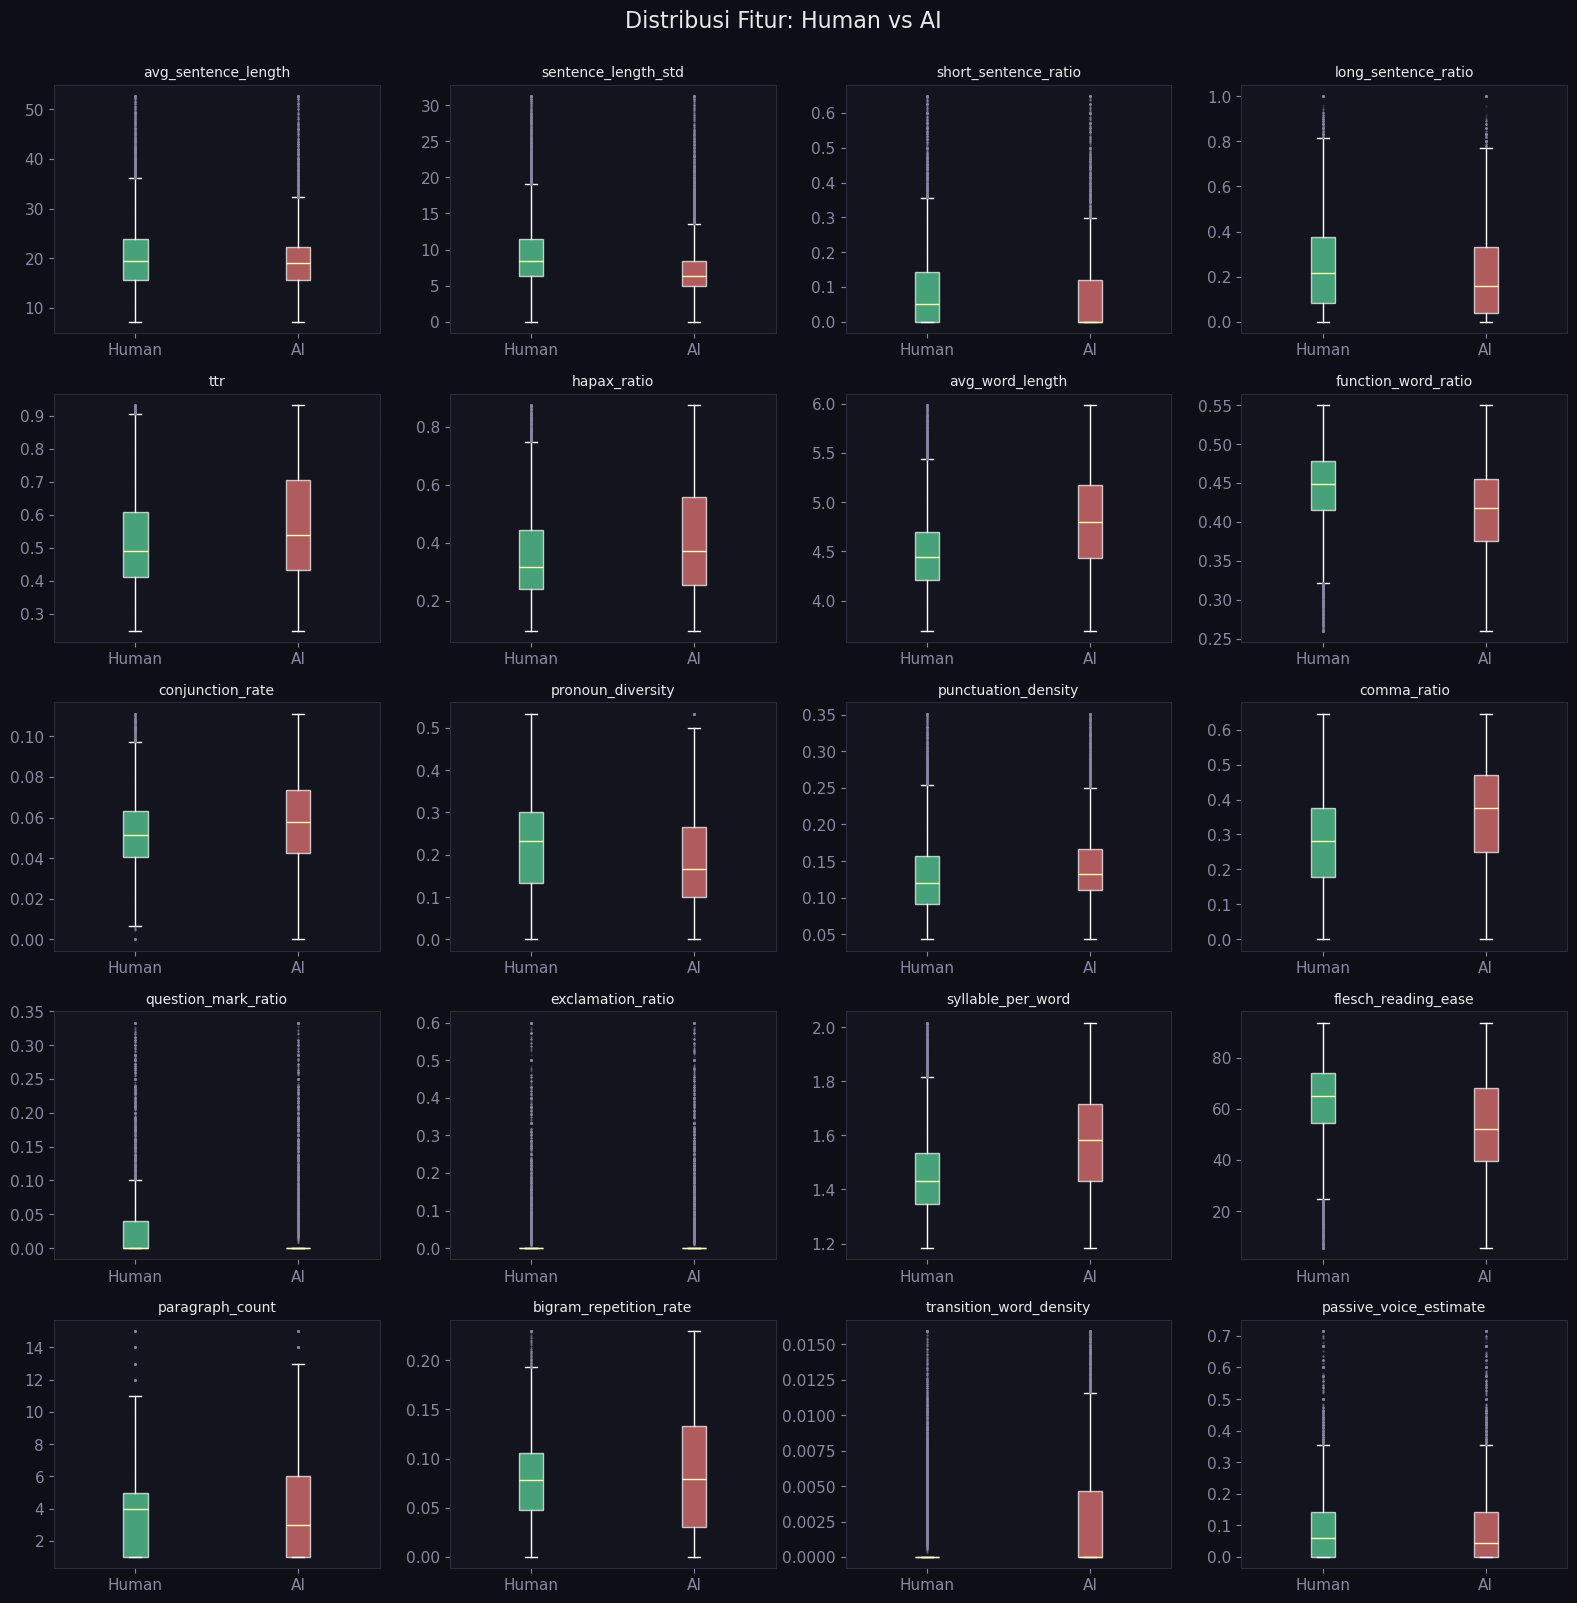

In [11]:
n_feat = len(feature_cols)
ncols = 4
nrows = int(np.ceil(n_feat / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.2*nrows))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    h = feat_df.loc[feat_df['label']==0, col].dropna()
    a = feat_df.loc[feat_df['label']==1, col].dropna()
    q_lo, q_hi = np.percentile(pd.concat([h, a]), [1, 99])
    h_c = h.clip(q_lo, q_hi)
    a_c = a.clip(q_lo, q_hi)
    bp = ax.boxplot([h_c, a_c], labels=['Human','AI'], patch_artist=True,
                    flierprops=dict(marker='o', markersize=1.5, alpha=0.3, markerfacecolor=MUTED, markeredgecolor='none'))
    for patch, c in zip(bp['boxes'], [GREEN, CORAL]):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    ax.set_title(col, fontsize=10)
    ax.grid(axis='y', alpha=0.15)

for j in range(i+1, len(axes)):
    axes[j].axis('off')

fig.suptitle("Distribusi Fitur: Human vs AI", fontsize=16, y=1.00)
plt.tight_layout()
savefig("feature_distributions.png")
plt.show()


## Section 8. Uji Statistik per Fitur
Buat tiap fitur hitung mean human, mean AI, Cohen's d (effect size), dan p-value Mann-Whitney U. Yang menarik buat ranking itu Cohen's d.

In [12]:
res = []
for col in feature_cols:
    h = feat_df.loc[feat_df['label']==0, col].dropna()
    a = feat_df.loc[feat_df['label']==1, col].dropna()
    mh, ma = h.mean(), a.mean()
    diff = ma - mh
    pooled = np.sqrt((h.std()**2 + a.std()**2) / 2)
    d = abs(diff / pooled) if pooled > 0 else 0.0
    try:
        _, pval = stats.mannwhitneyu(h, a, alternative='two-sided')
    except Exception:
        pval = np.nan
    res.append({
        "feature": col,
        "mean_human": mh,
        "mean_ai": ma,
        "diff": diff,
        "cohens_d": d,
        "pval": pval,
    })

res_df = pd.DataFrame(res).sort_values("cohens_d", ascending=False).reset_index(drop=True)
print(res_df.to_string(index=False))


                feature  mean_human   mean_ai      diff  cohens_d          pval
      syllable_per_word    1.455061  1.580977  0.125917  0.701247  0.000000e+00
        avg_word_length    4.481787  4.813640  0.331853  0.697691  0.000000e+00
    function_word_ratio    0.443399  0.413072 -0.030327  0.513082  0.000000e+00
transition_word_density    0.001007  0.002824  0.001817  0.499699  0.000000e+00
            comma_ratio    0.278395  0.352550  0.074155  0.484230  0.000000e+00
    flesch_reading_ease   62.394337 52.792254 -9.602083  0.445208  0.000000e+00
      pronoun_diversity    0.223521  0.185518 -0.038003  0.329259  0.000000e+00
            hapax_ratio    0.358053  0.414685  0.056632  0.308567 2.337748e-279
                    ttr    0.520719  0.570345  0.049626  0.301279  0.000000e+00
    punctuation_density    0.129978  0.148452  0.018474  0.277638  0.000000e+00
       conjunction_rate    0.052443  0.058292  0.005849  0.271961  0.000000e+00
    sentence_length_std    9.636439  7.7

## Section 9. Ranking Fitur (Bar Chart Cohen's d)
Visualisasi ranking. Threshold: d > 0.3 = effect medium (TEAL), 0.15 sampai 0.3 = small (AMBER), di bawah 0.15 = lemah (MUTED).

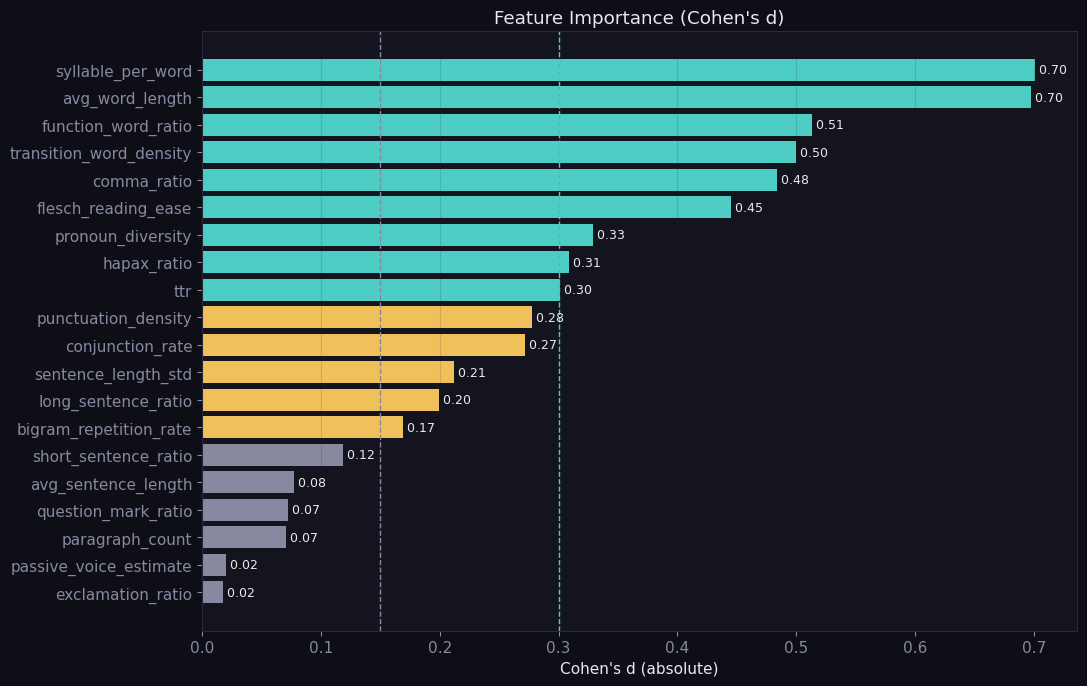

In [13]:
order = res_df.sort_values("cohens_d", ascending=True)
colors = []
for d in order["cohens_d"]:
    if d > 0.3:
        colors.append(TEAL)
    elif d >= 0.15:
        colors.append(AMBER)
    else:
        colors.append(MUTED)

fig, ax = plt.subplots(figsize=(11, max(6, len(order)*0.35)))
ax.barh(order["feature"], order["cohens_d"], color=colors)
ax.axvline(0.15, color=MUTED, ls='--', lw=1)
ax.axvline(0.30, color=TEAL,  ls='--', lw=1)
ax.set_xlabel("Cohen's d (absolute)")
ax.set_title("Feature Importance (Cohen's d)")
ax.grid(axis='x', alpha=0.15)
for i, v in enumerate(order["cohens_d"]):
    ax.text(v, i, " {:.2f}".format(v), va='center', fontsize=9)
plt.tight_layout()
savefig("feature_importance_eda.png")
plt.show()


## Section 10. Correlation Heatmap
Lihat fitur yang redundant. Kalau ada pasangan korelasi > 0.85, salah satunya kandidat di-drop (pilih yang Cohen's d-nya lebih kecil).

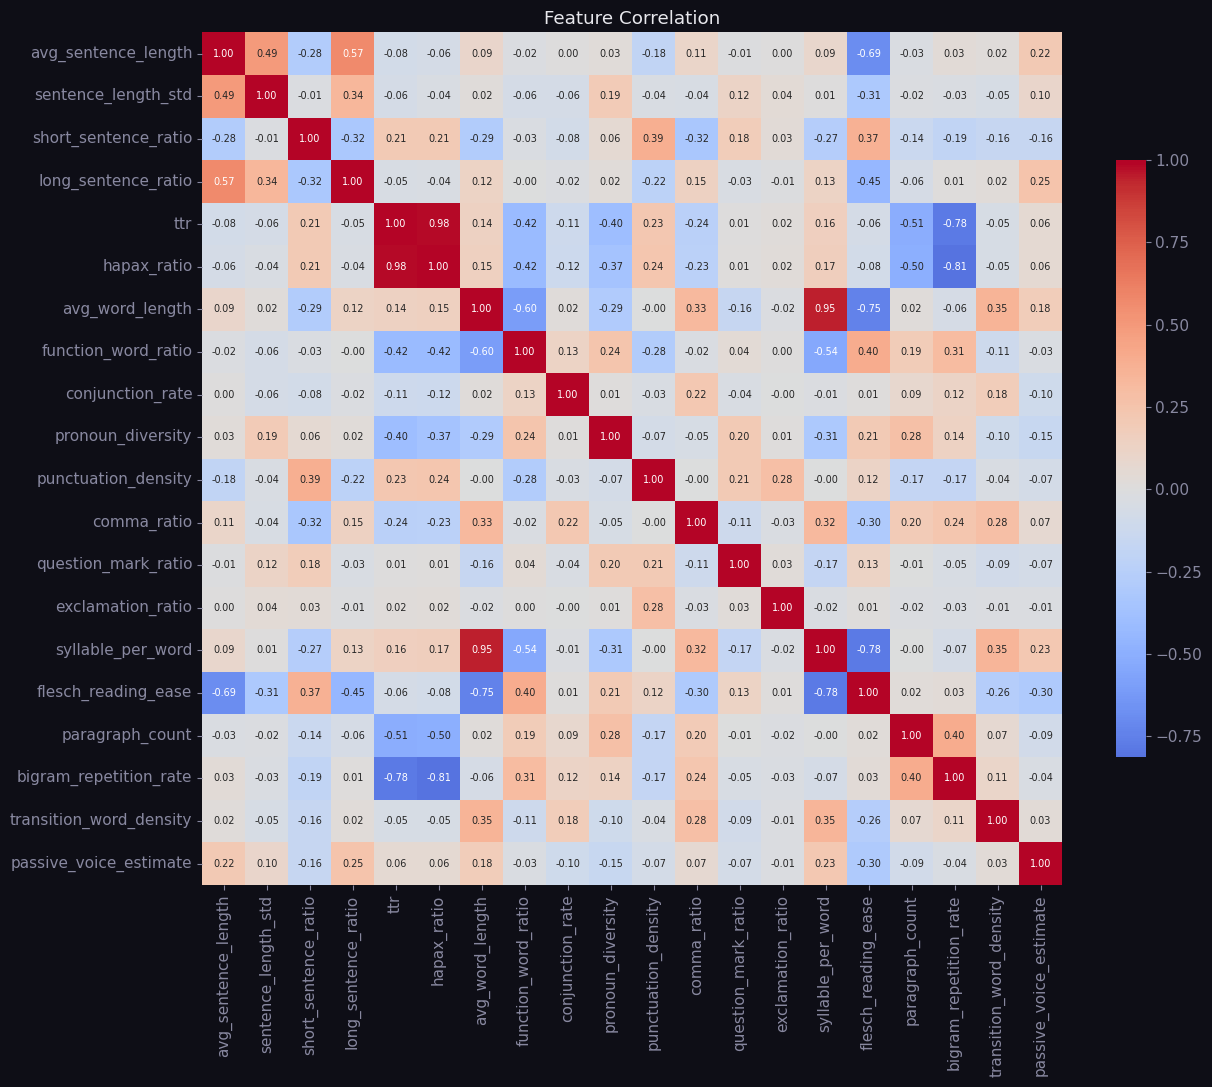

Pasangan fitur dengan |korelasi| > 0.85:
  ttr <-> hapax_ratio : 0.984
  avg_word_length <-> syllable_per_word : 0.947


In [14]:
corr = feat_df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            cbar_kws={'shrink': 0.7}, annot_kws={"size": 7})
ax.set_title("Feature Correlation")
plt.tight_layout()
savefig("feature_correlation.png")
plt.show()

corr_abs = corr.abs()
pairs = []
for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        v = corr_abs.iloc[i, j]
        if v > 0.85:
            pairs.append((feature_cols[i], feature_cols[j], float(v)))

print("Pasangan fitur dengan |korelasi| > 0.85:")
if pairs:
    for a, b, v in pairs:
        print(" ", a, "<->", b, ":", round(v, 3))
else:
    print(" (nggak ada)")


## Section 11. Seleksi Fitur Final
Aturannya: Cohen's d minimal 0.15, terus kalau ada pasangan korelasi tinggi (> 0.85) ambil yang d-nya lebih besar. Target 10 sampai 15 fitur.

In [15]:
d_map = dict(zip(res_df['feature'], res_df['cohens_d']))

selected = [f for f in feature_cols if d_map[f] >= 0.15]
dropped_weak = [f for f in feature_cols if d_map[f] < 0.15]

for a, b, v in pairs:
    if a in selected and b in selected:
        if d_map[a] >= d_map[b]:
            selected.remove(b)
        else:
            selected.remove(a)

selected = sorted(selected, key=lambda x: -d_map[x])

print("Fitur terpilih ({}):".format(len(selected)))
for f in selected:
    print("  +", f, "  d={:.3f}".format(d_map[f]))

print()
print("Di-drop karena Cohen's d < 0.15:")
for f in dropped_weak:
    print("  -", f, "  d={:.3f}".format(d_map[f]))

dropped_corr = [f for f in feature_cols if f not in selected and f not in dropped_weak]
if dropped_corr:
    print()
    print("Di-drop karena redundant (korelasi tinggi):")
    for f in dropped_corr:
        print("  -", f, "  d={:.3f}".format(d_map[f]))


Fitur terpilih (12):
  + syllable_per_word   d=0.701
  + function_word_ratio   d=0.513
  + transition_word_density   d=0.500
  + comma_ratio   d=0.484
  + flesch_reading_ease   d=0.445
  + pronoun_diversity   d=0.329
  + hapax_ratio   d=0.309
  + punctuation_density   d=0.278
  + conjunction_rate   d=0.272
  + sentence_length_std   d=0.212
  + long_sentence_ratio   d=0.199
  + bigram_repetition_rate   d=0.169

Di-drop karena Cohen's d < 0.15:
  - avg_sentence_length   d=0.077
  - short_sentence_ratio   d=0.118
  - question_mark_ratio   d=0.072
  - exclamation_ratio   d=0.018
  - paragraph_count   d=0.071
  - passive_voice_estimate   d=0.020

Di-drop karena redundant (korelasi tinggi):
  - ttr   d=0.301
  - avg_word_length   d=0.698


Penjelasan singkat keputusannya:

Fitur dengan Cohen's d di bawah 0.15 dianggap nggak cukup bedain human vs AI, jadi kita drop biar model nggak belajar dari sinyal yang lemah. Buat pasangan yang korelasinya tinggi (> 0.85), salah satu dibuang karena praktis ngangkat informasi yang sama, dan yang dipertahankan adalah yang Cohen's d-nya lebih besar. Hasil akhirnya antara 10 sampai 15 fitur yang siap masuk training.

## Section 12. Hitung Range Human/AI per Fitur
Buat tiap fitur terpilih, hitung range tipikal pakai percentile (bukan min/max biar nggak ke-pengaruh outlier). Disimpan ke JSON buat dipakai backend/app.

In [16]:
ranges = {}
for f in selected:
    h = feat_df.loc[feat_df['label']==0, f].dropna()
    a = feat_df.loc[feat_df['label']==1, f].dropna()
    all_v = feat_df[f].dropna()
    ranges[f] = {
        "human_low":  float(np.percentile(h, 15)),
        "human_high": float(np.percentile(h, 85)),
        "ai_low":     float(np.percentile(a, 15)),
        "ai_high":    float(np.percentile(a, 85)),
        "scale_min":  float(np.percentile(all_v, 2)),
        "scale_max":  float(np.percentile(all_v, 98)),
    }

with open("../data/processed/feature_ranges.json", "w") as fp:
    json.dump(ranges, fp, indent=2)

print("Saved -> data/processed/feature_ranges.json")
print()
for f, r in list(ranges.items())[:5]:
    print(f)
    for k, v in r.items():
        print(" ", k, "=", round(v, 3))
    print()


Saved -> data/processed/feature_ranges.json

syllable_per_word
  human_low = 1.307
  human_high = 1.597
  ai_low = 1.356
  ai_high = 1.789
  scale_min = 1.211
  scale_max = 1.953

function_word_ratio
  human_low = 0.394
  human_high = 0.493
  ai_low = 0.35
  ai_high = 0.476
  scale_min = 0.286
  scale_max = 0.536

transition_word_density
  human_low = 0.0
  human_high = 0.003
  ai_low = 0.0
  ai_high = 0.007
  scale_min = 0.0
  scale_max = 0.013

comma_ratio
  human_low = 0.123
  human_high = 0.429
  ai_low = 0.167
  ai_high = 0.512
  scale_min = 0.0
  scale_max = 0.6

flesch_reading_ease
  human_low = 47.525
  human_high = 78.325
  ai_low = 33.075
  ai_high = 76.303
  scale_min = 14.303
  scale_max = 90.529



## Section 13. Simpan Dataset Final

In [17]:
final_cols = selected + ['label', 'dataset']
features_final = feat_df[final_cols].copy()

features_final.to_csv("../data/processed/features_final.csv", index=False)

print("Saved -> data/processed/features_final.csv")
print("Shape:", features_final.shape)
print()
print("Label distribution:")
print(features_final['label'].value_counts())
print()
print("Fitur final ({}):".format(len(selected)))
for f in selected:
    print(" ", f)


Saved -> data/processed/features_final.csv
Shape: (74866, 14)

Label distribution:
label
0    42371
1    32495
Name: count, dtype: int64

Fitur final (12):
  syllable_per_word
  function_word_ratio
  transition_word_density
  comma_ratio
  flesch_reading_ease
  pronoun_diversity
  hapax_ratio
  punctuation_density
  conjunction_rate
  sentence_length_std
  long_sentence_ratio
  bigram_repetition_rate


## Section 14. Key Findings

**Total fitur diekstrak.** 20 fitur stylometric dari sekitar 44 ribu essay DAIGT v2 plus 30 ribu sample MAGE (15k human + 15k AI), totalnya sekitar 74 ribu sampel teks.

**Seleksi fitur.** Pakai dua aturan: Cohen's d minimal 0.15 dan drop pasangan yang korelasinya > 0.85. Dari 20 fitur, 12 yang lolos seleksi, 6 di-drop karena effect-nya lemah, 2 di-drop karena redundant.

**Fitur paling kuat.** Top 5 berdasarkan Cohen's d: `syllable_per_word` (0.70), `function_word_ratio` (0.51), `transition_word_density` (0.50), `comma_ratio` (0.48), dan `flesch_reading_ease` (0.45). Kebanyakan dari kategori readability, word choice, dan punctuation. Ini masuk akal karena AI cenderung pakai kata yang lebih panjang/kompleks, lebih banyak transition words (however, therefore, dll), dan lebih banyak koma.

**Fitur yang ternyata lemah.** Yang nggak diduga: `avg_sentence_length` cuma dapet d=0.077, padahal awalnya dikira bakal jadi fitur kuat. Ternyata rata-rata panjang kalimat human dan AI cukup overlap. `exclamation_ratio` (0.018) dan `passive_voice_estimate` (0.020) juga hampir nggak ada bedanya antar kelas.

**Yang di-drop karena redundant.** `avg_word_length` (d=0.698) korelasinya tinggi sama `syllable_per_word` (d=0.701), jadi yang dipertahanin syllable karena d-nya lebih tinggi. Sama halnya `ttr` (d=0.301) redundant sama `hapax_ratio` (d=0.309).

**Catatan soal transition_word_density.** Fitur ini punya range yang mulai dari 0 di kedua kelas (banyak teks yang nggak punya transition words). Effect size-nya tinggi (0.50) tapi distribusinya sparse, jadi di app nanti visualisasinya mungkin kurang informatif. Tetap dipertahanin buat model tapi perlu dicatat sebagai limitasi.

**Range buat app.** Tiap fitur terpilih udah dihitung range tipikal human dan AI pakai percentile 15/85, plus scale min/max pakai percentile 2/98. Disimpan di `feature_ranges.json`, siap di-copy ke `backend/ml/`.
